In [ ]:
#Handling Missing Value — Titanic-Dataset.csv
import pandas as pd

path = "Titanic-Dataset.csv"
df = pd.read_csv(path)

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [2]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [3]:
percent_missing = 100 * df.isnull().mean()
percent_missing

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [4]:
df_filled = df.copy()

In [5]:
df_filled['Age'] = df_filled['Age'].fillna(
    df_filled['Age'].mean()
)

In [6]:
df_filled['Embarked'] = df_filled['Embarked'].fillna(
    df_filled['Embarked'].mode().iloc[0]
)

In [7]:
df_filled = df_filled.drop(columns='Cabin')

In [8]:
df_filled.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [10]:
#Handling Outliers — diabetes.csv
import matplotlib.pyplot as plt
import numpy as np

path = "diabetes.csv"
df2 = pd.read_csv(path)

df2

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
columns_to_plot = ['Glucose', 'BloodPressure', 'BMI']
columns_to_plot = [col for col in columns_to_plotif col in df2.columns]

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20936\3509386677.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20936\3509386677.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20936\3509386677.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)


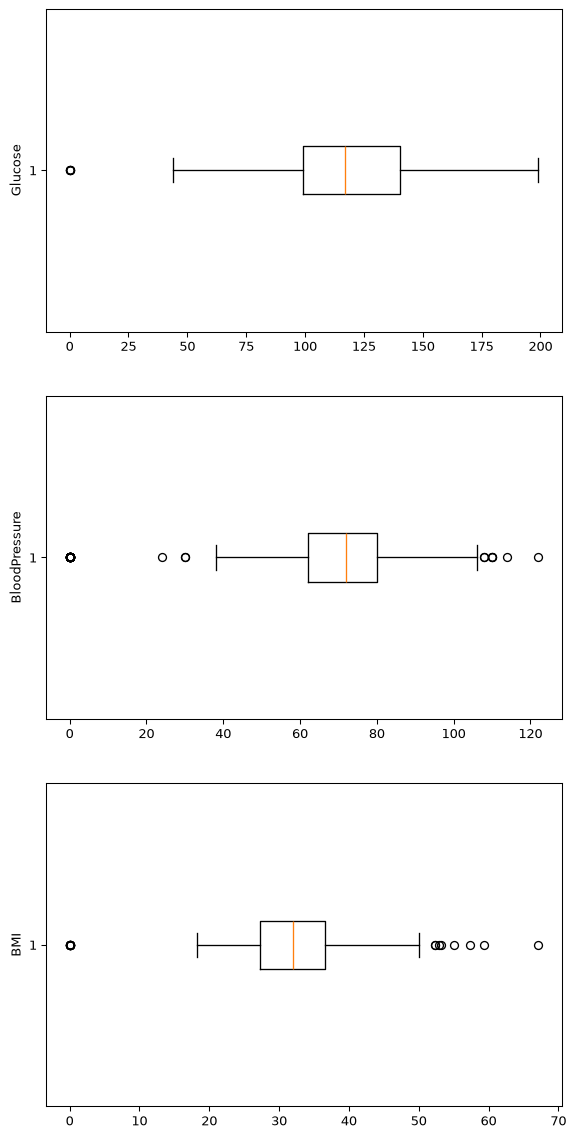

In [ ]:
fig, axs = plt.subplots(len(columns_to_plot),1,dpi=95,figsize=(7, 5 * len(columns_to_plot)))
if len(columns_to_plot) == 1:
    axs = [axs]
for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(df2[col], vert=False)
    axs[i].set_ylabel(col)
plt.show()

In [ ]:
def remove_outliers_sequentially(df2, columns):
    df_cleaned = df2.copy()
    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) &(df_cleaned[col] <= upper_bound)]
    return df_cleaned

In [ ]:
clean_data = remove_outliers_sequentially(df2,['Glucose', 'BloodPressure', 'BMI'])

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20936\1667786002.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20936\1667786002.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20936\1667786002.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)


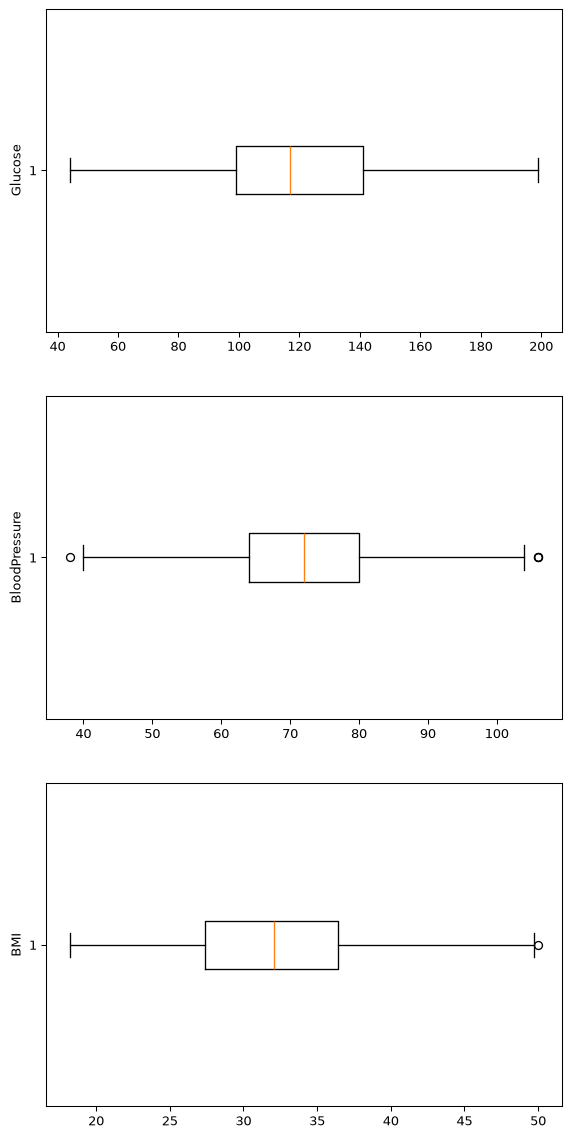

In [ ]:
columns_to_plot = ['Glucose', 'BloodPressure', 'BMI']
fig, axs = plt.subplots(len(columns_to_plot),1,dpi=95,figsize=(7, 5 * len(columns_to_plot)))
if len(columns_to_plot) == 1:axs = [axs]
for i, col in enumerate(columns_to_plot):axs[i].boxplot(clean_data[col], vert=False)axs[i].set_ylabel(col)
plt.show()